# News Scraping and Sentiment Analysis using NewsAPI

## Overview

In this project, we fetch news articles from **NewsAPI**, clean the text, perform **sentiment analysis**, and visualize results. This approach works for any keyword/topic globally and provides insights into:

- Sentiment distribution of news articles.
- Word frequencies (WordCloud visualization).
- Distribution of articles across news sources.
- Sentiment per source.
- Sentiment trends over time.

This is more flexible than scraping a single website because **NewsAPI aggregates multiple sources** in real-time.

---

## How NewsAPI Works

1. **NewsAPI Endpoint**:  
   - We use the `https://newsapi.org/v2/everything` endpoint to fetch articles.
   - Parameters include:
     - `q`: Keyword/topic to search for.
     - `language`: Language of the articles (e.g., 'en' for English).
     - `pageSize`: Number of articles to fetch.
     - `apiKey`: Your API key to access the NewsAPI service.

2. **Fetching Data**:
   - We send an HTTP GET request to the API.
   - Response is in JSON format containing metadata, article titles, descriptions, content, source, and published date.

3. **DataFrame Construction**:
   - Convert JSON response to a pandas DataFrame for easy analysis.
   - Columns include: `source`, `author`, `title`, `description`, `content`, `url`, `publishedAt`.

---

## Text Cleaning

Before analysis, text is **cleaned** to remove noise:

- HTML tags removed using **BeautifulSoup**.
- Unicode normalized.
- Lowercased.
- Punctuation and numbers removed using **regular expressions**.
- Stopwords removed using **NLTK**.
- Lemmatization applied to reduce words to their base form.

This prepares the text for **WordCloud visualization and sentiment analysis**.

---

## Sentiment Analysis

- **TextBlob** library is used to compute sentiment polarity.
- Polarity score ranges from **-1 (negative) to +1 (positive)**.
- We classify each article as:
  - **Positive**: polarity > 0.1
  - **Negative**: polarity < -0.1
  - **Neutral**: otherwise

This allows us to visualize sentiment distribution across all articles.

---

## Visualizations

1. **Sentiment Distribution**: Shows counts of positive, neutral, and negative articles.  
2. **WordCloud**: Highlights the most frequent words after cleaning.  
3. **Articles per Source**: How many articles are fetched from each news source.  
4. **Sentiment per Source**: Shows how each news source reports positively, negatively, or neutrally.  
5. **Sentiment Trend Over Time**: Polarity score plotted over the article's publish date.

---

## What is Happening in the Code

1. **Fetch Articles**:
   - Use `fetch_news(query)` function to query NewsAPI and return a DataFrame.
2. **Clean Text**:
   - Apply `clean_text()` on the content column to remove noise.
3. **Analyze Sentiment**:
   - Use `analyze_sentiment()` to assign sentiment category and polarity score to each article.
4. **Extract Source Names**:
   - Extract the source name for grouping and visualization.
5. **Visualization**:
   - Multiple plots provide insights:
     - Count plots for sentiment distribution.
     - Bar plots for sources and sentiment per source.
     - WordCloud for most frequent words.
     - Line plot for sentiment trend over time.
6. **Dashboard (Elegant Version)**:
   - All visualizations combined in one figure using subplots for easy classroom presentation.

---

## Advantages of Using NewsAPI

- Aggregates **multiple news sources** automatically.
- Can filter by **language, date, or keyword**.
- Avoids website-specific scraping issues (like dynamic content or paywalls).
- Enables **quick analysis** and **visualization** of news trends.

---



# NewsAPI Dashboard

In [14]:
import pandas as pd
import requests
import nltk
import re
import string
import unicodedata
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup


# NLTK Setup
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Functions

def clean_text(text):
    if not text:
        return ""
    text = BeautifulSoup(text, "html.parser").get_text()
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r'[^a-z\s]', ' ', text.lower())
    tokens = [lemmatizer.lemmatize(w) for w in nltk.word_tokenize(text) if w not in stop_words and len(w) > 1]
    return " ".join(tokens)

def analyze_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return 'Positive', polarity
    elif polarity < -0.1:
        return 'Negative', polarity
    else:
        return 'Neutral', polarity

def fetch_news(query, language='en', page_size=100):
    API_URL = 'https://newsapi.org/v2/everything'
    api_key = ''
    params = {'q': query, 'language': language, 'pageSize': page_size, 'apiKey': api_key}
    resp = requests.get(API_URL, params=params)
    data = resp.json()
    if data.get('status') != 'ok':
        print("Error fetching news:", data)
        return pd.DataFrame()
    df = pd.DataFrame(data['articles'])
    df = df[['source','author','title','description','content','url','publishedAt']]
    return df

def process_news(query):
    df = fetch_news(query)
    if df.empty:
        return None
    df['content_cleaned'] = df['content'].fillna(df['description']).apply(clean_text)
    df[['Sentiment','Polarity']] = df['content_cleaned'].apply(lambda x: pd.Series(analyze_sentiment(x)))
    df['source_name'] = df['source'].apply(lambda x: x['name'] if isinstance(x, dict) else str(x))
    df['publishedAt'] = pd.to_datetime(df['publishedAt'])
    return df

In [16]:
# Run Pipeline
query = "Delhi"
df_news = process_news(query)

if df_news is not None and not df_news.empty:
    print(f"Total Articles: {len(df_news)}")
    display(df_news[['title','Sentiment','Polarity','source_name']].head())

Total Articles: 100


,title,Sentiment,Polarity,source_name
0,New Delhi Pollution Hits Five-Year High,Positive,0.205556,Slashdot.org
1,Drone shows New Delhi covered in smog after Di...,Positive,0.186932,Yahoo Entertainment
2,Explosion near Red Fort in India's New Delhi k...,Neutral,0.051515,Yahoo Entertainment
3,I moved back to my home city after a year abro...,Positive,0.177083,Business Insider
4,Delhi's alleged car bomb attacker named by inv...,Neutral,0.033333,BBC News


/tmp/ipython-input-3924106660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df_news, palette=['green','grey','red'], ax=axes[0,0])
/tmp/ipython-input-3924106660.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=source_counts.index, palette='coolwarm', ax=axes[1,0])


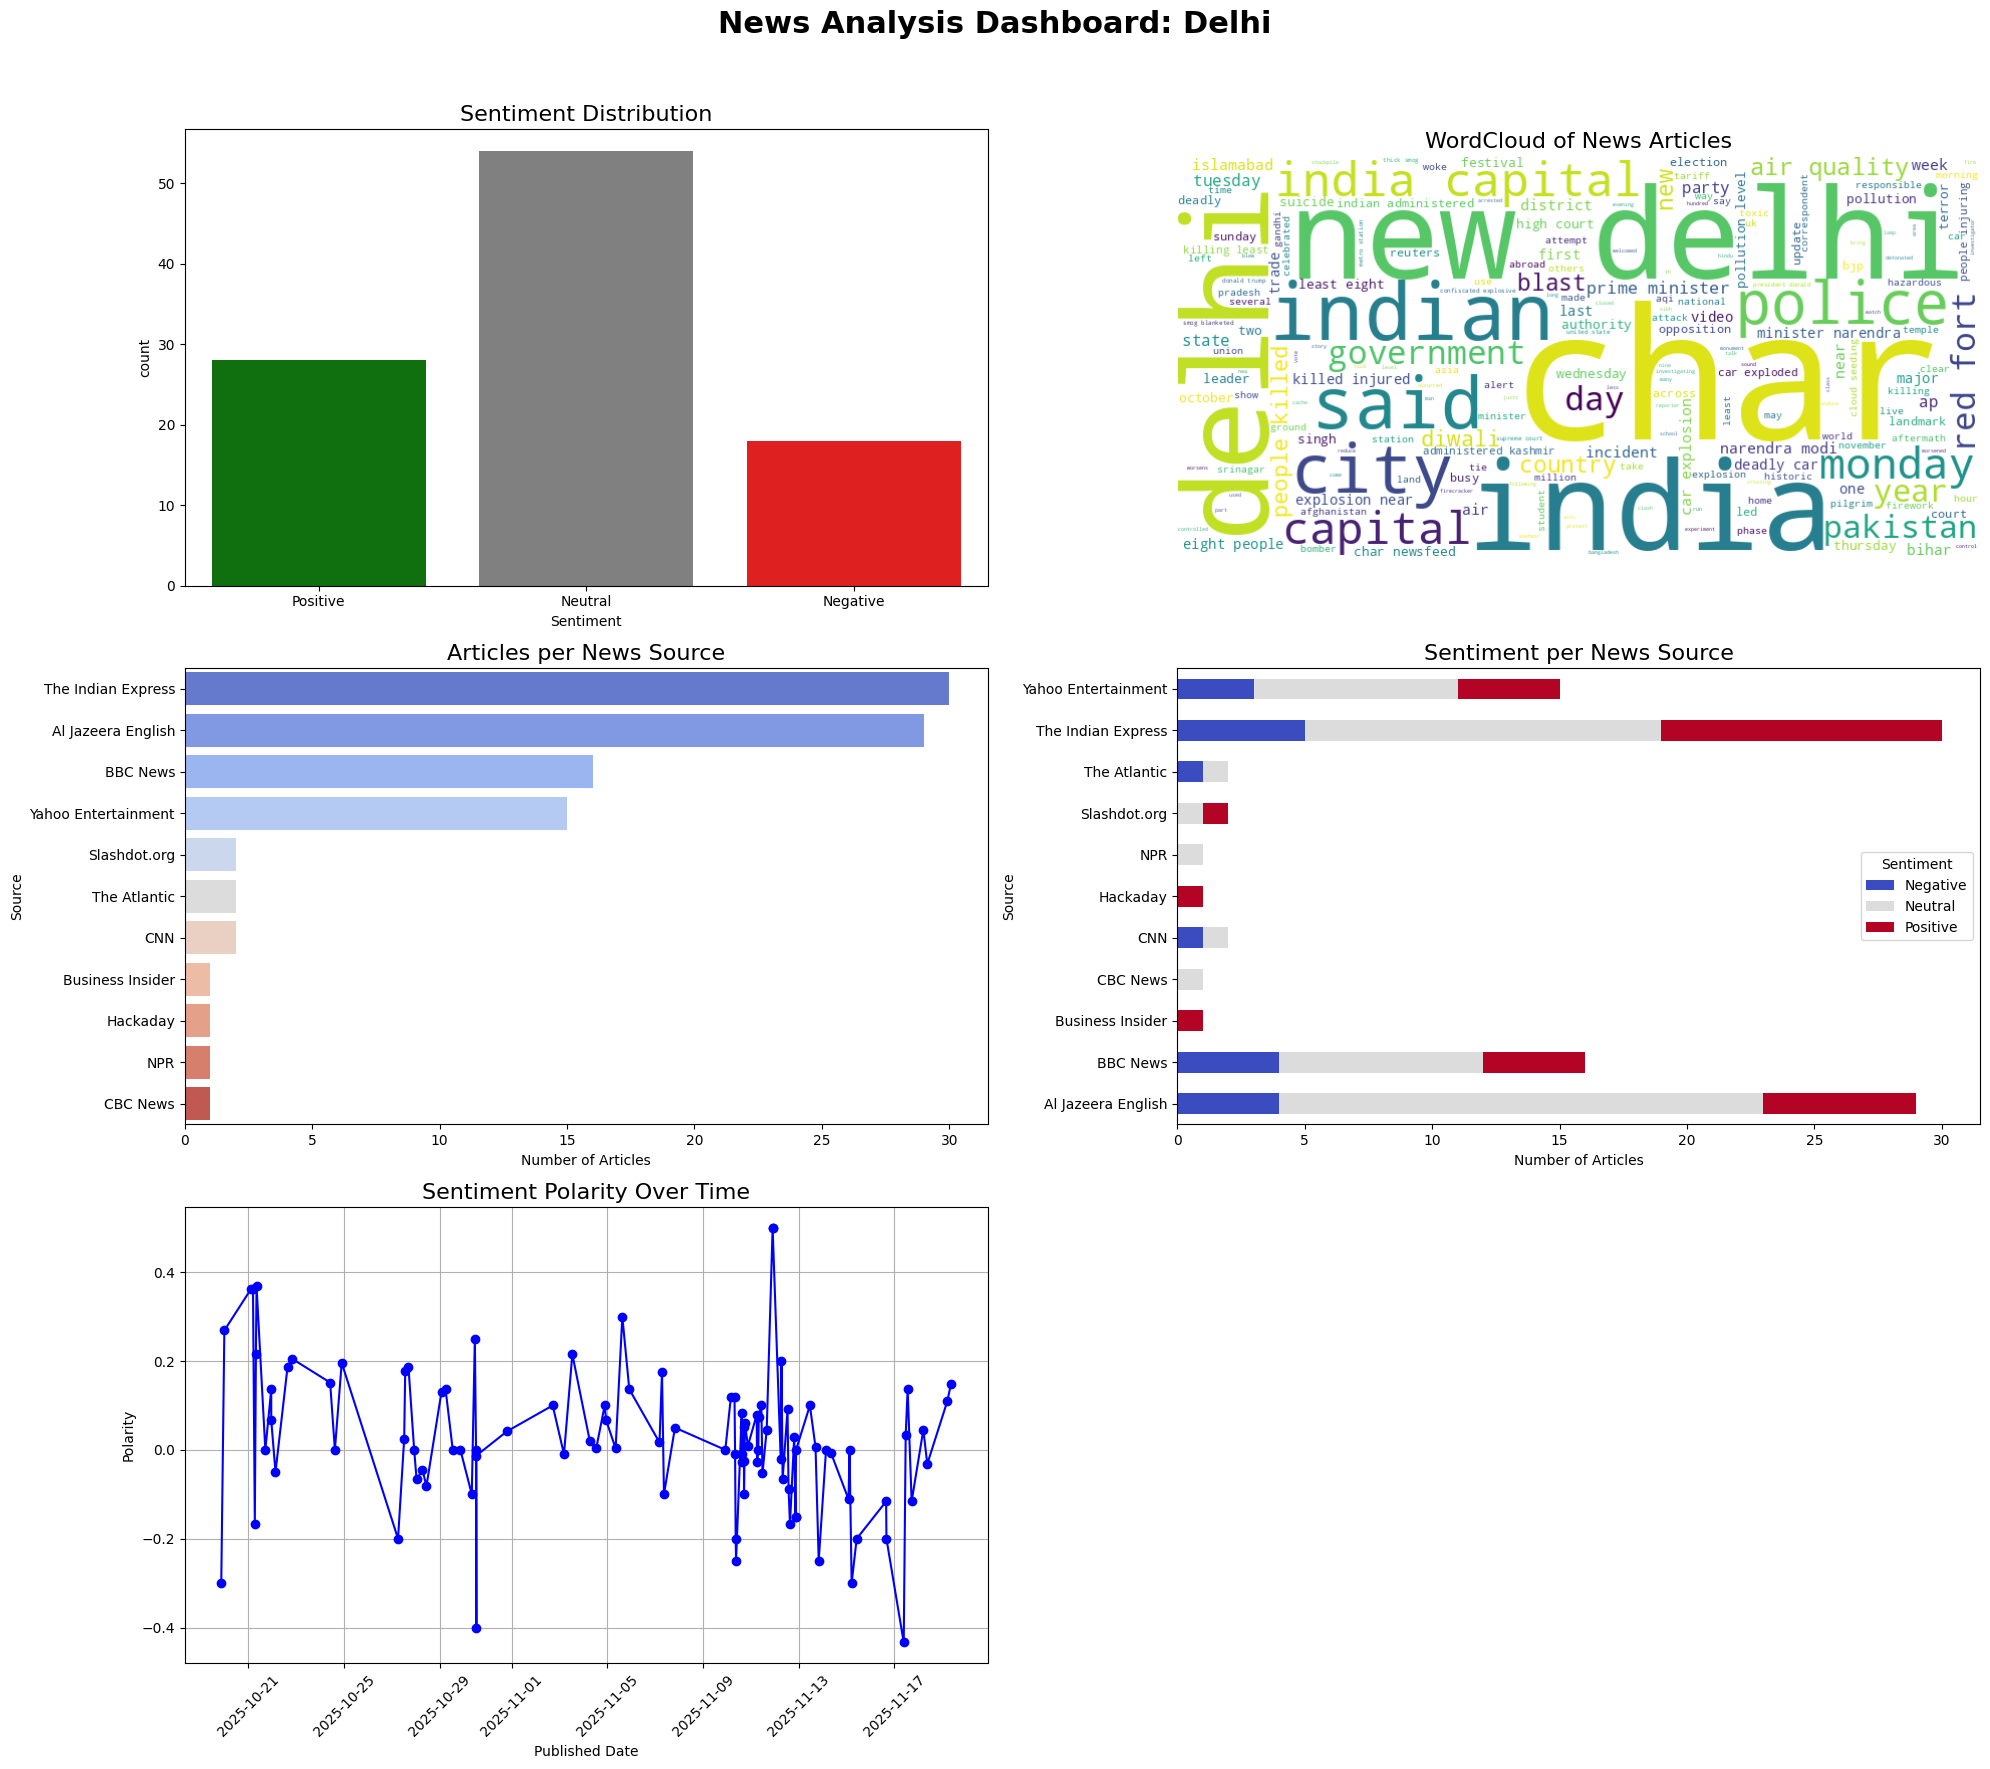

In [17]:

# Dashboard

if df_news is not None and not df_news.empty:
    fig, axes = plt.subplots(3, 2, figsize=(20,18))
    fig.suptitle(f"News Analysis Dashboard: {query}", fontsize=22, fontweight='bold')

    # 1. Sentiment distribution
    sns.countplot(x='Sentiment', data=df_news, palette=['green','grey','red'], ax=axes[0,0])
    axes[0,0].set_title('Sentiment Distribution', fontsize=16)

    # 2. WordCloud
    all_text = " ".join(df_news['content_cleaned'].tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_text)
    axes[0,1].imshow(wordcloud, interpolation='bilinear')
    axes[0,1].axis('off')
    axes[0,1].set_title('WordCloud of News Articles', fontsize=16)

    # 3. Articles per source
    source_counts = df_news['source_name'].value_counts()
    sns.barplot(x=source_counts.values, y=source_counts.index, palette='coolwarm', ax=axes[1,0])
    axes[1,0].set_title('Articles per News Source', fontsize=16)
    axes[1,0].set_xlabel('Number of Articles')
    axes[1,0].set_ylabel('Source')

    # 4. Sentiment per source
    source_sentiment = df_news.groupby(['source_name','Sentiment']).size().unstack(fill_value=0)
    source_sentiment.plot(kind='barh', stacked=True, colormap='coolwarm', ax=axes[1,1])
    axes[1,1].set_title('Sentiment per News Source', fontsize=16)
    axes[1,1].set_xlabel('Number of Articles')
    axes[1,1].set_ylabel('Source')

    # 5. Sentiment trend over time
    df_news_sorted = df_news.sort_values('publishedAt')
    axes[2,0].plot(df_news_sorted['publishedAt'], df_news_sorted['Polarity'], marker='o', linestyle='-', color='blue')
    axes[2,0].set_title('Sentiment Polarity Over Time', fontsize=16)
    axes[2,0].set_xlabel('Published Date')
    axes[2,0].set_ylabel('Polarity')
    axes[2,0].tick_params(axis='x', rotation=45)
    axes[2,0].grid(True)

    # Hide unused subplot
    axes[2,1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
else:
    print("No news articles found.")
